In [1]:
from statsbombpy import sb

match_id = 3895158  # Leverkusen vs Dortmund, from your original portfolio
events = sb.events(match_id)
events.head()

C:\Users\pryde\Documents\Football\Analysis\match-report-tool\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 3421, 'lineup': [{'player': {'id...",Bayer Leverkusen,904,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'formation': 4231, 'lineup': [{'player': {'id...",Borussia Dortmund,180,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Borussia Dortmund,180,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Bayer Leverkusen,904,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Borussia Dortmund,180,00:00:00.000,Half Start,NaN


In [2]:
matches = sb.matches(competition_id=9, season_id=281)
match_info = matches[matches['match_id'] == match_id]
match_info[['home_team', 'away_team', 'home_score', 'away_score']]

C:\Users\pryde\Documents\Football\Analysis\match-report-tool\venv\Lib\site-packages\statsbombpy\api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,home_team,away_team,home_score,away_score
2,Bayer Leverkusen,Borussia Dortmund,1,1


In [3]:
possession_counts = events.groupby('possession_team')['possession'].nunique()
possession_pct = (possession_counts / possession_counts.sum() * 100).round(1)
possession_pct

possession_team
Bayer Leverkusen     58.1
Borussia Dortmund    41.9
Name: possession, dtype: float64

In [4]:
shots = events[events['type'] == 'Shot']
shots_by_team = shots.groupby('team').size()
goals_by_team = shots[shots['shot_outcome'] == 'Goal'].groupby('team').size()

print("Shots per team:")
print(shots_by_team)
print("\nGoals per team:")
print(goals_by_team)

Shots per team:
team
Bayer Leverkusen     24
Borussia Dortmund     6
dtype: int64

Goals per team:
team
Bayer Leverkusen     1
Borussia Dortmund    1
dtype: int64


In [6]:
import numpy as np
import statsmodels.api as sm

shots = shots.copy()
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])
shots['distance_to_goal'] = np.sqrt((120 - shots['x'])**2 + (40 - shots['y'])**2) * 0.9144
shots['is_goal'] = (shots['shot_outcome'] == 'Goal').astype(int)
shots['is_header'] = (shots['shot_body_part'] == 'Head').astype(int)
shots['is_open_play'] = (shots['shot_type'] == 'Open Play').astype(int)
shots['under_pressure'] = shots['under_pressure'].fillna(False).astype(int)

goal_width = 7.32
shots['angle'] = np.abs(np.arctan2(
    goal_width * (120 - shots['x']),
    (120 - shots['x'])**2 + np.abs(40 - shots['y']) * (np.abs(40 - shots['y']) + goal_width)
))

In [7]:
xg_by_team = shots.groupby('team')['shot_statsbomb_xg'].sum().round(2)
print("xG per team:")
print(xg_by_team)

xG per team:
team
Bayer Leverkusen     2.14
Borussia Dortmund    0.81
Name: shot_statsbomb_xg, dtype: float64


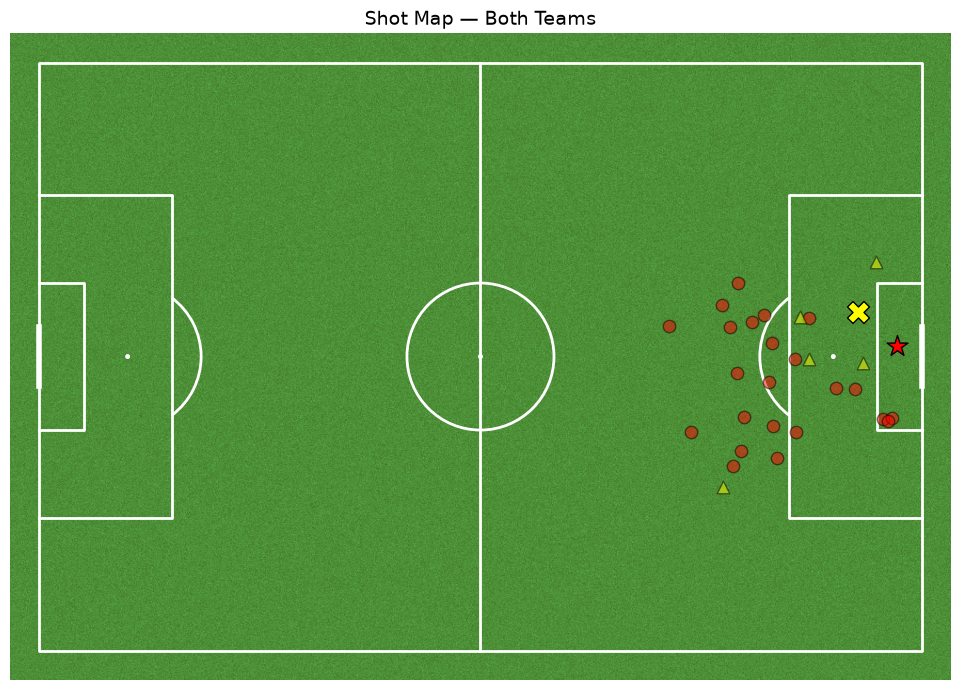

In [8]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

for team, color in [('Bayer Leverkusen', 'red'), ('Borussia Dortmund', 'yellow')]:
    team_shots = shots[shots['team'] == team]
    goals = team_shots[team_shots['shot_outcome'] == 'Goal']
    non_goals = team_shots[team_shots['shot_outcome'] != 'Goal']
    
    pitch.scatter(non_goals['x'], non_goals['y'], ax=ax, color=color, edgecolors='black', 
                  s=80, alpha=0.5, marker='o' if team == 'Bayer Leverkusen' else '^')
    pitch.scatter(goals['x'], goals['y'], ax=ax, color=color, edgecolors='black', 
                  s=250, marker='*' if team == 'Bayer Leverkusen' else 'X')

plt.title('Shot Map — Both Teams', fontsize=14)
plt.savefig('shot_map.png', dpi=150, bbox_inches='tight')
plt.show()

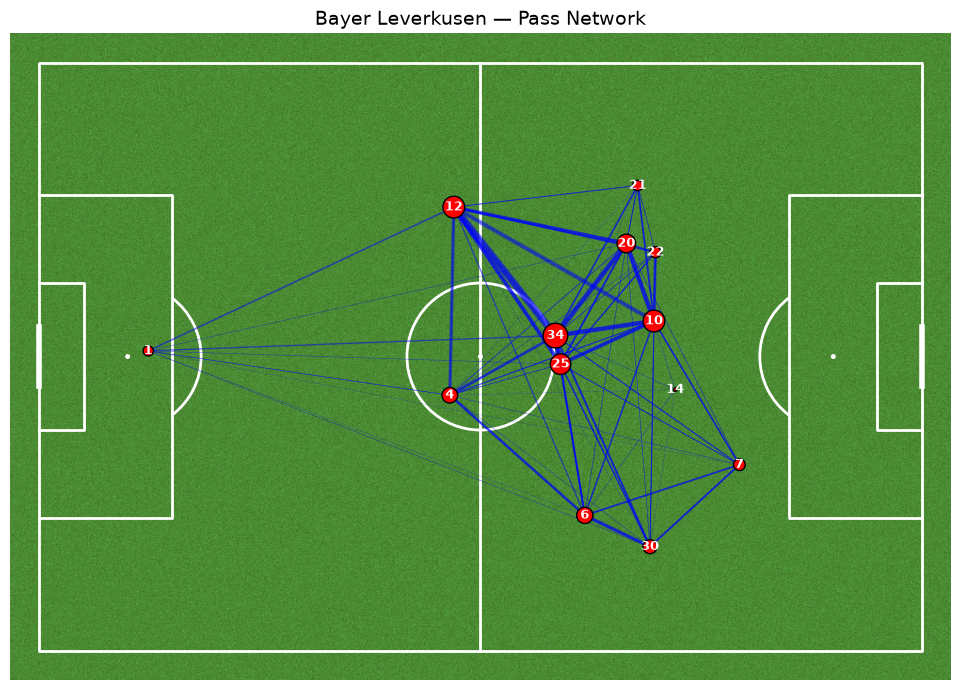

In [9]:
completed_passes = events[(events['type'] == 'Pass') & 
                           (events['team'] == 'Bayer Leverkusen') & 
                           (events['pass_outcome'].isna())]

completed_passes = completed_passes.copy()
completed_passes['x'] = completed_passes['location'].apply(lambda loc: loc[0])
completed_passes['y'] = completed_passes['location'].apply(lambda loc: loc[1])

avg_locations = completed_passes.groupby('player').agg({'x': 'mean', 'y': 'mean', 'id': 'count'})
avg_locations.columns = ['x', 'y', 'pass_count']

pass_pairs = completed_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')
pass_pairs = pass_pairs.sort_values('pass_count', ascending=False)

lineups = sb.lineups(match_id)
number_map = lineups['Bayer Leverkusen'].set_index('player_name')['jersey_number']
avg_locations['jersey_number'] = avg_locations.index.map(number_map)

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

for _, row in pass_pairs.iterrows():
    passer, recipient, count = row['player'], row['pass_recipient'], row['pass_count']
    if passer in avg_locations.index and recipient in avg_locations.index:
        x1, y1 = avg_locations.loc[passer, ['x', 'y']]
        x2, y2 = avg_locations.loc[recipient, ['x', 'y']]
        ax.plot([x1, x2], [y1, y2], color='blue', linewidth=count/5, alpha=0.5, zorder=1)

pitch.scatter(avg_locations['x'], avg_locations['y'], s=avg_locations['pass_count']*3, 
              color='red', edgecolors='black', ax=ax, zorder=2)

for player, row in avg_locations.iterrows():
    ax.annotate(str(int(row['jersey_number'])), xy=(row['x'], row['y']),
                ha='center', va='center', fontsize=9, color='white', weight='bold', zorder=3)

plt.title('Bayer Leverkusen — Pass Network', fontsize=14)
plt.savefig('pass_network.png', dpi=150, bbox_inches='tight')
plt.show()

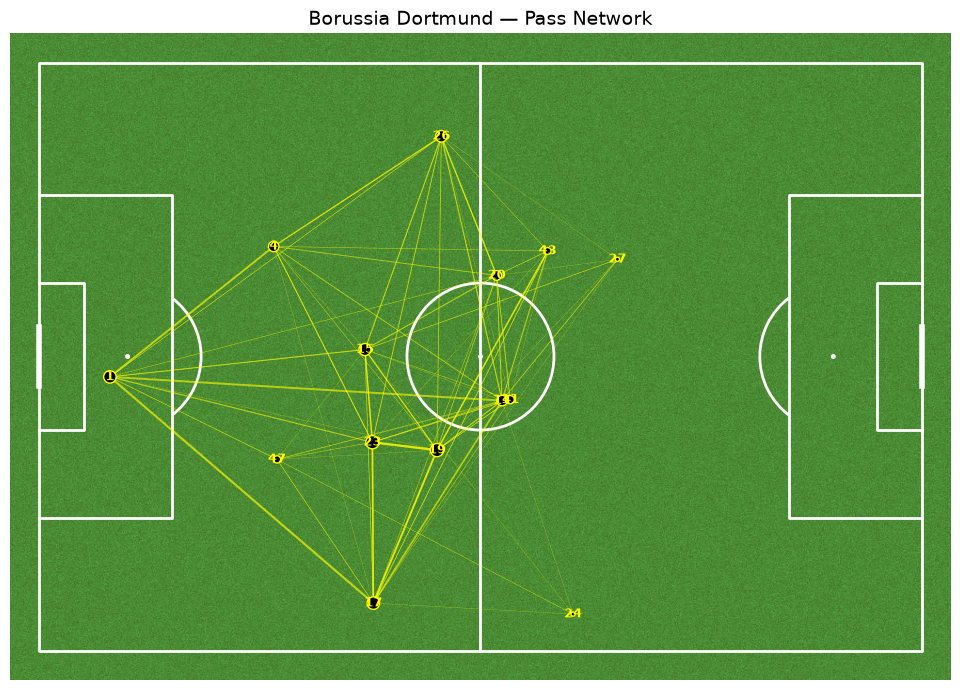

In [10]:
completed_passes_dortmund = events[(events['type'] == 'Pass') & 
                                     (events['team'] == 'Borussia Dortmund') & 
                                     (events['pass_outcome'].isna())]

completed_passes_dortmund = completed_passes_dortmund.copy()
completed_passes_dortmund['x'] = completed_passes_dortmund['location'].apply(lambda loc: loc[0])
completed_passes_dortmund['y'] = completed_passes_dortmund['location'].apply(lambda loc: loc[1])

avg_locations_d = completed_passes_dortmund.groupby('player').agg({'x': 'mean', 'y': 'mean', 'id': 'count'})
avg_locations_d.columns = ['x', 'y', 'pass_count']

pass_pairs_d = completed_passes_dortmund.groupby(['player', 'pass_recipient']).size().reset_index(name='pass_count')

number_map_d = lineups['Borussia Dortmund'].set_index('player_name')['jersey_number']
avg_locations_d['jersey_number'] = avg_locations_d.index.map(number_map_d)

pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(10, 7))

for _, row in pass_pairs_d.iterrows():
    passer, recipient, count = row['player'], row['pass_recipient'], row['pass_count']
    if passer in avg_locations_d.index and recipient in avg_locations_d.index:
        x1, y1 = avg_locations_d.loc[passer, ['x', 'y']]
        x2, y2 = avg_locations_d.loc[recipient, ['x', 'y']]
        ax.plot([x1, x2], [y1, y2], color='yellow', linewidth=count/5, alpha=0.6, zorder=1)

pitch.scatter(avg_locations_d['x'], avg_locations_d['y'], s=avg_locations_d['pass_count']*3,
              color='black', edgecolors='yellow', ax=ax, zorder=2)

for player, row in avg_locations_d.iterrows():
    ax.annotate(str(int(row['jersey_number'])), xy=(row['x'], row['y']),
                ha='center', va='center', fontsize=9, color='yellow', weight='bold', zorder=3)

plt.title('Borussia Dortmund — Pass Network', fontsize=14)
plt.savefig('pass_network_dortmund.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
tackles = events[events['type'] == 'Duel']
interceptions = events[events['type'] == 'Interception']
fouls = events[events['type'] == 'Foul Committed']

tackles_by_team = tackles.groupby('team').size()
interceptions_by_team = interceptions.groupby('team').size()
fouls_by_team = fouls.groupby('team').size()

print("Duels (tackles/challenges) per team:")
print(tackles_by_team)
print("\nInterceptions per team:")
print(interceptions_by_team)
print("\nFouls committed per team:")
print(fouls_by_team)

Duels (tackles/challenges) per team:
team
Bayer Leverkusen     27
Borussia Dortmund    37
dtype: int64

Interceptions per team:
team
Bayer Leverkusen     10
Borussia Dortmund    11
dtype: int64

Fouls committed per team:
team
Bayer Leverkusen     14
Borussia Dortmund    12
dtype: int64


In [12]:
key_events = events[events['type'].isin(['Substitution', 'Bad Behaviour'])]
goals_timeline = shots[shots['shot_outcome'] == 'Goal'][['minute', 'team', 'player']]

print("Goals:")
print(goals_timeline)
print("\nSubstitutions / Cards:")
print(key_events[['minute', 'team', 'player', 'type']])

Goals:
      minute               team                player
3633       4  Borussia Dortmund        Julian Ryerson
3659      78   Bayer Leverkusen  Victor Okoh Boniface

Substitutions / Cards:
      minute               team                        player           type
3853      63   Bayer Leverkusen                 Jonas Hofmann   Substitution
3854      63  Borussia Dortmund            Nico Schlotterbeck   Substitution
3855      64  Borussia Dortmund  Jamie Jermaine Bynoe-Gittens   Substitution
3856      78   Bayer Leverkusen   Exequiel Alejandro Palacios   Substitution
3857      83  Borussia Dortmund                    Marco Reus   Substitution
3864      90  Borussia Dortmund                   Marius Wolf  Bad Behaviour
3865      90   Bayer Leverkusen               Odilon Kossonou  Bad Behaviour
